In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [6]:
df = pd.read_csv('titanic/train.csv', index_col = 0)

In [3]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.size

9801

In [7]:
df.shape

(891, 11)

So, we have 891 rows and 11 columns, the ultimate goal - detect who survives - binary classification

Columns - Name, sex, age, sibsp, parch, ticket, fare, cabin, embarked

In [8]:
df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

We have 5 numerical data - survived, pclass, sibsp, parch, fare and 5 categorical data - object

Gotta do smth with ticket - either remove it , it  can;t be encoded and I am very unsure what different ticket may indicate

In [10]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

so, we have zero null values, except in age - 177 null values, cabin - 687, embarked - 2 

We can decide what to do with them - some can be dropped, some for example is almost fully null - feels like okay to drop? but first gott figure out the importance of this column

In [13]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Like here we see that mean age is 30, we can do either this with null age values - fill null values in range of ~30

Based on this describe stats, what we infer:

age: mean = 29.7, median (50%) = 28 -> normal distribution, but anomaly - 177 missing values. Since mean and median close -> no skeweness, mostly symmetric

survived: man = 0.38 -> 38% survived -> most died, std = 0.48 high but okay for binary values, median = 0, most died

pclass: mean = 2.31 -> class 2 and 3 prevalent, median = 3 most were 3rd class, 75 % = 3, most passengers were 3rd class -> passengers motly were poor

sibsp: mean = 0.52, median = 0 -> mostly traveled alone, 75% had 0 or 1 family members, max = 8 unusual, maybe outlier, gotta do smth with it

parch: parents + children abroad -> mostly no parents/chidlren together, mean = 0.38 and 50% = 0, no parents and children traveling together

fare: crazy anomalies - mean = 32 and median = 14 huge difference -> skewed, min = 0 (why 0 maybe crew or data error??) and max = 512 huge difference, while 75% is only 31, std = 49 bigger than mean, extremely high variation

All insights so far


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


Let's see unique values of each column to understand what we will need to decode/encode later or just get to know more


In [16]:
df['Pclass'].unique()

array([3, 1, 2])

In [19]:
# content of unique values
df['Cabin'].unique()

# number of unique values
df['Cabin'].nunique()

147

and etc

# work wih visualizations

In [20]:
# bar plot, histogram, scatter plot, box plot, line plot

Bar plots used to visualize categorical data. For example, we could have used it to compare how many people survived and how many didn't or difference in survival between genders, how different was number of people in every class (1, 2, 3)

In [23]:
women = len(df[(df['Survived'] == 1) & (df['Sex'] == 'female')])

In [24]:
women

233

In [25]:
men = len(df[(df['Survived'] == 1) & (df['Sex'] == 'male')])

In [26]:
men

109

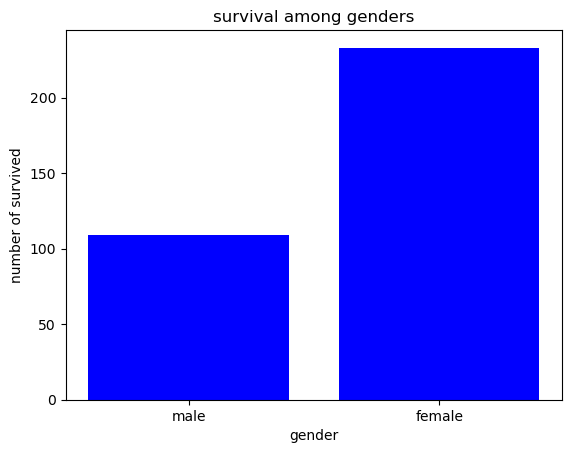

In [27]:
gender = ['male', 'female']
number = [109, 233]

plt.bar(gender, number, color='blue')
plt.title('survival among genders')
plt.xlabel('gender')
plt.ylabel('number of survived')
plt.show()

Histogram for continuous data spread outs (test scoress, heights, temperatures), no gaps in comparison to bar plots that are used for distinct groups. 

I can use it for age or fare, mostly we use graphs to reveal some info or insights, so these should tell us about inequalities, which we noticed by describe are existent in age and fare columns

Histogram help to reveal skeweness (shape of distribution), outliers, then in feature engineering and preprocessing it needs to be addressed - skewed data or smth or maybe use models that okay with this.  


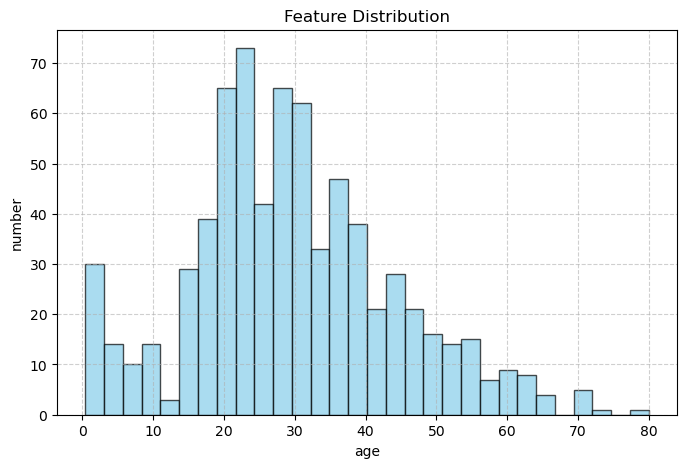

In [29]:
data = df['Age']

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Feature Distribution')
plt.xlabel('age')
plt.ylabel('number')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

it is not really symmetric, if it was symmetric =, we would see peak right in the middle, which is not true, perfect number in right and left, more values on the right - right skewed, if it was more values on left - left skewed

more advanced - can add some line over graph that would openly hightlight that

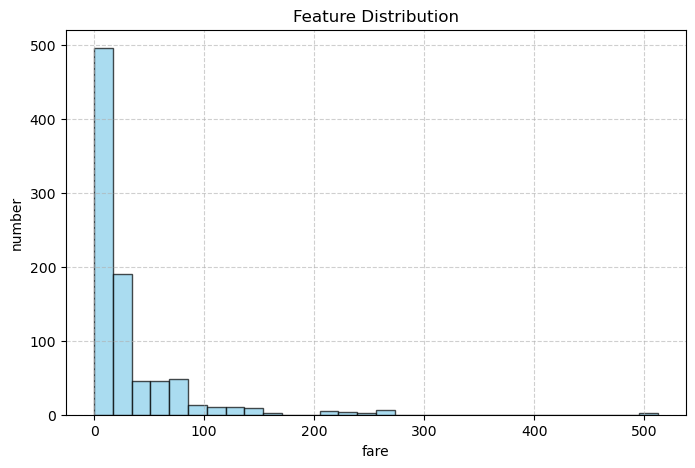

In [30]:
data = df['Fare']

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Feature Distribution')
plt.xlabel('fare')
plt.ylabel('number')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## scatterplot

This is used to see correlation, if existent or not is positive there is correlation between x and y and as x increases, y increases, in case of negative if x increases, y decreases

what we could see - as example, maybe rich people survived more frequently than poor people? and lost of other insights we can take, but for now I will only do 1 graph cause I am running out of time


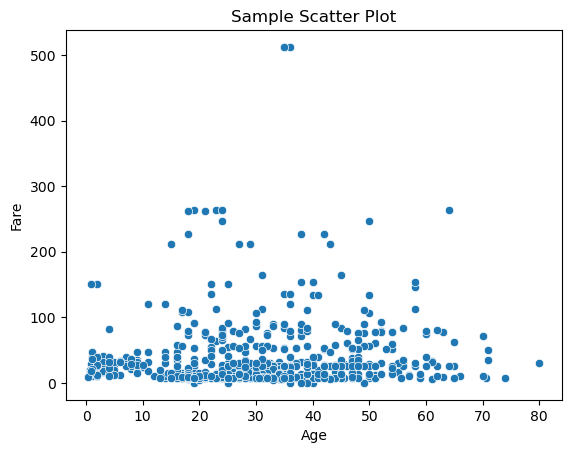

In [33]:
data = df

sns.scatterplot(data=data, x='Age', y='Fare')
plt.title("Sample Scatter Plot")
plt.show()

interesting: the most expensive tickets of 500 were bought by people of age in range 30-40 and what i can also infer is that most children had usual price of tickets, so mostly parents with children weren't rich (?)

## box plot 

reveal important info about outliers, extreme cases, where is mean/median. observing data symmetry, and identifying the spread of data when basic averages (like the mean) are misleading

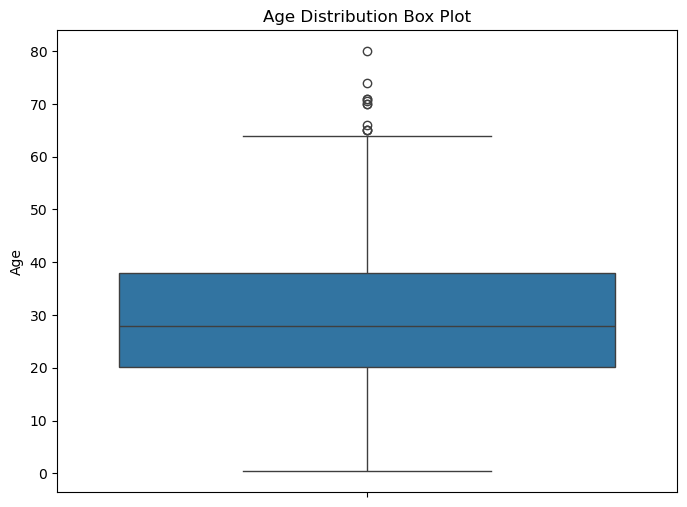

In [37]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'])
plt.title("Age Distribution Box Plot")
plt.ylabel("Age")
plt.show()

## last but not least - line plot

C:\Users\gtokebaeva\AppData\Local\Temp\ipykernel_8144\295183831.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups = df.groupby(pd.cut(df['Age'].dropna(), bins=10))['Survived'].mean()


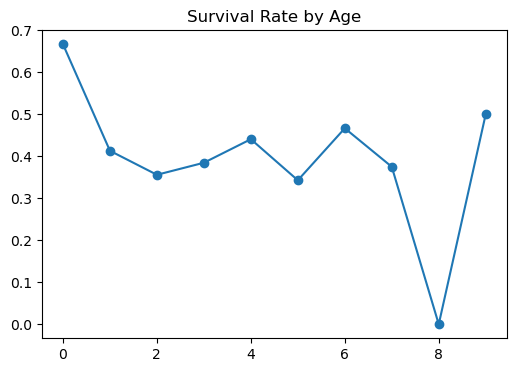

In [38]:
plt.figure(figsize=(6,4))
age_groups = df.groupby(pd.cut(df['Age'].dropna(), bins=10))['Survived'].mean()
plt.plot(range(len(age_groups)), age_groups.values, marker='o')
plt.title('Survival Rate by Age')
plt.show()


# Day 2 - tasks:

- EDA (describing stats, distribution, correlations, outliers)

- Missing values (mean / median / mode / forward-fill)

- Encoding (Label Encoding, One-Hot Encoding)

- Scaling (MinMaxScaler, StandardScaler)

- Feature Engineering (creating new features on basis of existing ones)


_Task_: complete full EDA on titanic dataset, make necessary changes


### EDA 
consists of:
- load data
- head, tail
- df.shape()
- df.info()
- df.describe()
- df.columns.tolist()
- df.isnull().sum()
- df.duplicated().sum()
- univariate analysis - plots (for example, bar plot, kernel plot to see skeweness and density, swarm plot or box plot for outliers)
- bivariate analysis - correlation between two variables (pair plot, violin plot, box plot)
- multivatiate analysis - correlation between three of more variables (correlation heatmap)

In [2]:
# I already did load data, head, and tail, now I will just repeat some

In [8]:
df.shape

(891, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [10]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# I explored this yesterday extensively and found some insights

In [12]:
df.columns.tolist()

['Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [13]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [17]:
# some null values in age - 177, cabin - 687, and embarked - 2. Gotta fix it after eda

In [15]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
# I guess zero duplicates

In [22]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
# Obviously, some columns can be skipped - like name, passengerID, they can be removed as they don't give any useful info. 
# I am interested in how Pclass, gender, sibsp, parch, ticket, fare, cabin, embarked influence survival rate - so I draw correlation map


In [27]:
df = df.drop(columns='Name')

In [28]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,female,35.0,1,0,113803,53.1000,C123,S
5,0,3,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,female,19.0,0,0,112053,30.0000,B42,S
889,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [30]:
# Before checking correlation, I better do encoding of categorical data - Label Encoding, One Hot Encoding

In [35]:
# gender - label encoding, embarked - one hot encoding, also i guess i gotta drop cabin too many null values

In [33]:
df = df.drop(columns='Cabin')

In [34]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
2,1,1,female,38.0,1,0,PC 17599,71.2833,C
3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
4,1,1,female,35.0,1,0,113803,53.1000,S
5,0,3,male,35.0,0,0,373450,8.0500,S


In [37]:
# missing values - age 177, embarked 2

In [39]:
# mostly, just use imputation (mean, mode, median) and also forward-fill but they useful for ordered or time-series data.
# the closest avaialble data will be used to fill out missing values, maybe inaccurate when gaps bi

In [40]:
df.loc[df['Embarked'].isnull(), 'Embarked'] = 'S'

In [41]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [43]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [44]:
# Use Mean for normally distributed numerical data, Median for skewed data or data with outliers, and Mode for categorical data. 

In [45]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [46]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

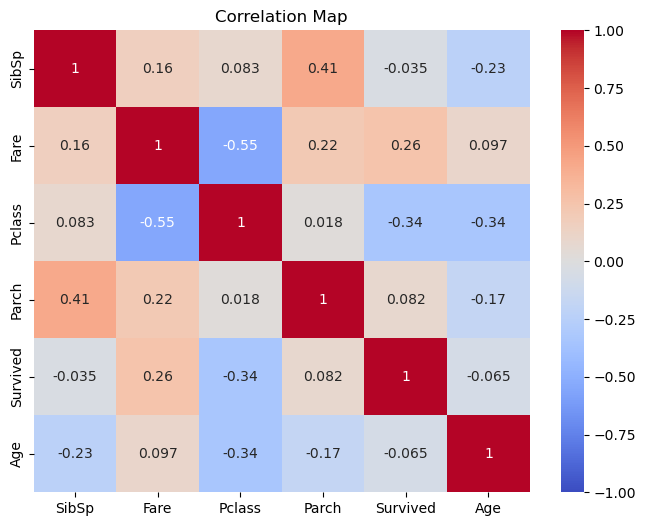

In [49]:
numerical_col = ['SibSp', 'Fare', 'Pclass', 'Parch', 'Survived', 'Age']
df1 = df[numerical_col]
correlation_matrix = df1.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Map')
plt.show()

In [50]:
# too small dataset, small number of columns = won't drop anything 

REST of EDA = plots I will leave for now and ask questions on today's meeting

## Encoding

In [51]:
encoding_columns = ['Sex', 'Embarked']

In [53]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis = 1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)


In [54]:
X

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
PassengerId,,,,,,,,
1,3,male,22.0,1,0,A/5 21171,7.2500,S
2,1,female,38.0,1,0,PC 17599,71.2833,C
3,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
4,1,female,35.0,1,0,113803,53.1000,S
5,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...
887,2,male,27.0,0,0,211536,13.0000,S
888,1,female,19.0,0,0,112053,30.0000,S
889,3,female,28.0,1,2,W./C. 6607,23.4500,S


In [57]:
# encoding of gender - label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
x_train_le = le.fit_transform(X_train['Sex'])
x_test_le = le.transform(X_test['Sex'])


In [59]:
x_train_le

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,

In [66]:
# encoding of embarked - one hot encoding

from sklearn.preprocessing import OneHotEncoder
ht = OneHotEncoder(sparse_output = False)
x_train_ht = ht.fit_transform(X_train[['Embarked']])
x_test_ht1 = ht.transform(X_test[['Embarked']])



## Scaling 

### standard scaler, minmaxscaler, robustscaler, maxabsscaler

what needs to be scaled - fare (robustscaler bcs of extreme outliers), 

age (minmaxscaler bcs skewed data, if it was normal distribution - standardscaler)

In [69]:
from sklearn.preprocessing import RobustScaler 

sc = RobustScaler()
x_train_sc = sc.fit_transform(X_train[['Fare']])
x_val_sc = sc.transform(X_test[['Fare']])

In [72]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()
x_train_ms = ms.fit_transform(X_train[['Age']])
x_val_ms = ms.transform(X_test[['Age']])

## Feature Engineering 

As example, _bmi_ a very important feature can be derived and made by using existing features - height and weight

Or, opposite way - create two new features out of existing one feature and etc

For example, age can be grouped into bins, name appearantly had deeper meaning wiht these miss, mr and etc

Better - first split, then feature engineering, then encoding, scaling, and etc

In [74]:
# this is a very quick way to check survival rate 
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Check survival by title
title_survival = df.groupby('Title')['Survived'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(title_survival)

KeyError: 'Name'

### gotta do EDA

- Describe does give information about distribution of dataset, yes, but it is not as detailed and don't give as much info as inidividual visualizations. 

- For example, to have a closer look at distributions - use histograms or boxplot, heatmap to see correlations between features and features and target value.

- Use barplots to see relationship between a survival and different features, like Pclass, Gender

- _for use_ = kaggle notebooks

- These distributions illustrated on missing values can be used to fill out null values



In [ ]:
# let's see relationship between Pclass and survival rate - barplots

# survival rate and parch relationship
data = df['Fare']

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Feature Distribution')
plt.xlabel('fare')
plt.ylabel('age')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()